<a href="https://colab.research.google.com/github/dinviiii/Face-Mask-Detection/blob/main/faceMask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementation 1 – Face Mask Image Classification System

Course: ICT 3212 – Introduction to Intelligent Systems  
University: Rajarata University of Sri Lanka  

Objective: To develop a baseline CNN model to classify images into With Mask and Without Mask categories.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/face_mask_project

/content/drive/MyDrive/face_mask_project


In [ ]:
!ls


dataset_split


In [ ]:
!ls dataset_split/test


 classes.csv	    'test_178 (1).jpg'	'test_182 (1).jpg'  'test_579 (1).jpg'
'test_174 (1).jpg'  'test_179 (1).jpg'	'test_183 (1).jpg'  'test_582 (1).jpg'
'test_175 (1).jpg'  'test_180 (1).jpg'	'test_184 (1).jpg'   WithMask
'test_176 (1).jpg'  'test_181 (1).jpg'	'test_185 (1).jpg'   WithoutMask
'test_177 (1).jpg'  'test_18 (1).jpg'	'test_186 (1).jpg'


In [ ]:
import os
import shutil
import pandas as pd

In [ ]:
os.makedirs("dataset_split/test/WithMask", exist_ok=True)
os.makedirs("dataset_split/test/WithoutMask", exist_ok=True)

In [ ]:
import pandas as pd
import os
import shutil

# Read CSV file
df = pd.read_csv("dataset_split/test/classes.csv")
df.head()

,filename,with_mask,without_mask
0,test_309.jpg,1,0
1,test_755.jpg,0,1
2,test_109.jpg,1,0
3,test_363.jpg,1,0
4,test_1152.jpg,1,0


In [ ]:
print(df.columns)

Index(['filename', 'with_mask', 'without_mask'], dtype='object')


In [ ]:
import os
import shutil
import pandas as pd

# Read CSV file
df = pd.read_csv("dataset_split/test/classes.csv")

# Create class folders inside test
os.makedirs("dataset_split/test/WithMask", exist_ok=True)
os.makedirs("dataset_split/test/WithoutMask", exist_ok=True)

# Move images based on CSV labels
for index, row in df.iterrows():
    filename = row['filename']
    source_path = os.path.join("dataset_split/test", filename)

    # Check if source image exists
    if not os.path.exists(source_path):
        print(f"File not found: {filename}")
        continue

    if row['with_mask'] == 1:
        destination = os.path.join("dataset_split/test/WithMask", filename)
    elif row['without_mask'] == 1:
        destination = os.path.join("dataset_split/test/WithoutMask", filename)
    else:
        continue

    shutil.move(source_path, destination)

print("Test images have been split successfully!")

# Verify counts
print("WithMask test images:", len(os.listdir("dataset_split/test/WithMask")))
print("WithoutMask test images:", len(os.listdir("dataset_split/test/WithoutMask")))


File not found: test_309.jpg
File not found: test_755.jpg
File not found: test_109.jpg
File not found: test_363.jpg
File not found: test_1152.jpg
File not found: test_211.jpg
File not found: test_449.jpg
File not found: test_225.jpg
File not found: test_1139.jpg
File not found: test_813.jpg
File not found: test_833.jpg
File not found: test_269.jpg
File not found: test_70.jpg
File not found: test_992.jpg
File not found: test_722.jpg
File not found: test_369.jpg
File not found: test_340.jpg
File not found: test_275.jpg
File not found: test_290.jpg
File not found: test_424.jpg
File not found: test_1113.jpg
File not found: test_559.jpg
File not found: test_266.jpg
File not found: test_140.jpg
File not found: test_572.jpg
File not found: test_302.jpg
File not found: test_157.jpg
File not found: test_32.jpg
File not found: test_69.jpg
File not found: test_287.jpg
File not found: test_761.jpg
File not found: test_324.jpg
File not found: test_163.jpg
File not found: test_94.jpg
File not found:

In [ ]:
!ls dataset_split/train

withMask  withoutMask


In [ ]:
print("Train WithMask:", len(os.listdir("dataset_split/train/withMask")))
print("Train WithoutMask:", len(os.listdir("dataset_split/train/withoutMask")))

print("Test WithMask:", len(os.listdir("dataset_split/test/WithMask")))
print("Test WithoutMask:", len(os.listdir("dataset_split/test/WithoutMask")))

Train WithMask: 9614
Train WithoutMask: 9737
Test WithMask: 644
Test WithoutMask: 635


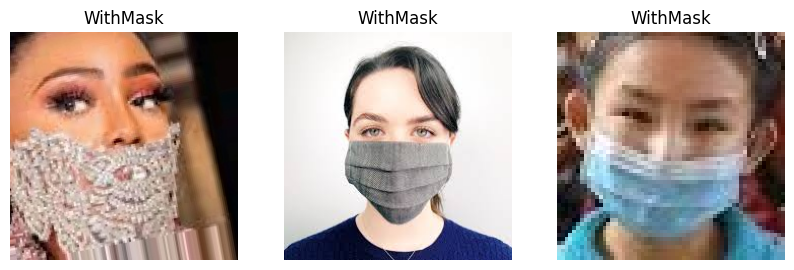

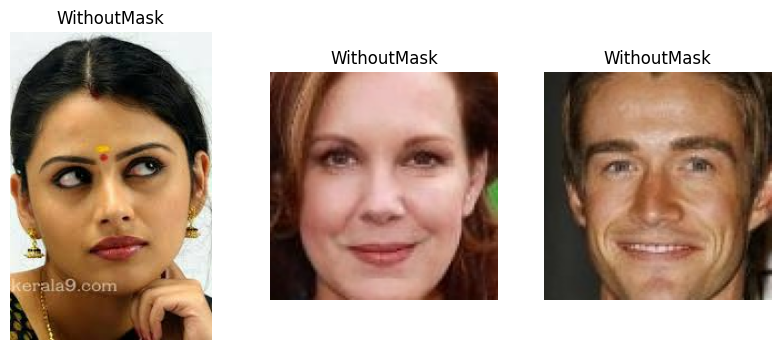

In [ ]:
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
import random
import os

# Function to display 3 random images from a folder
def show_samples(folder, label):
    files = os.listdir(folder)
    samples = random.sample(files, 3)
    plt.figure(figsize=(10,4))
    for i, img_file in enumerate(samples):
        img = mpimg.imread(os.path.join(folder, img_file))
        plt.subplot(1,3,i+1)
        plt.imshow(img)
        plt.title(label)
        plt.axis('off')
    plt.show()

show_samples("dataset_split/train/withMask", "WithMask")
show_samples("dataset_split/train/withoutMask", "WithoutMask")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data augmentation + normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,      # Normalize pixel values
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1  # Reserve 10% for validation
)

# Test data: only normalization
test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_directory(
    'dataset_split/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'   # training data
)

# Validation generator
validation_generator = train_datagen.flow_from_directory(
    'dataset_split/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'  # validation data
)

# Test generator
test_generator = test_datagen.flow_from_directory(
    'dataset_split/test',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 17417 images belonging to 2 classes.
Found 1934 images belonging to 2 classes.
Found 1279 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=10  # You can adjust epochs
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 25/544 ━━━━━━━━━━━━━━━━━━━━ 1:27:47 10s/step - accuracy: 0.5331 - loss: 1.4737

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


544/544 ━━━━━━━━━━━━━━━━━━━━ 6237s 11s/step - accuracy: 0.8369 - loss: 0.4258 - val_accuracy: 0.8906 - val_loss: 0.2590
Epoch 2/10
  1/544 ━━━━━━━━━━━━━━━━━━━━ 10:25 1s/step - accuracy: 0.9375 - loss: 0.2154

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


544/544 ━━━━━━━━━━━━━━━━━━━━ 31s 55ms/step - accuracy: 0.9375 - loss: 0.2154 - val_accuracy: 0.9000 - val_loss: 0.2508
Epoch 3/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 539s 992ms/step - accuracy: 0.9322 - loss: 0.1722 - val_accuracy: 0.9031 - val_loss: 0.2338
Epoch 4/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.9375 - loss: 0.1564 - val_accuracy: 0.9031 - val_loss: 0.2463
Epoch 5/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 589s 982ms/step - accuracy: 0.9468 - loss: 0.1335 - val_accuracy: 0.8797 - val_loss: 0.2951
Epoch 6/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.9062 - loss: 0.2154 - val_accuracy: 0.8859 - val_loss: 0.2820
Epoch 7/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 562s 1s/step - accuracy: 0.9490 - loss: 0.1241 - val_accuracy: 0.8943 - val_loss: 0.2661
Epoch 8/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.9375 - loss: 0.0944 - val_accuracy: 0.8964 - val_loss: 0.2641
Epoch 9/10
544/544 ━━━━━━━━━━━━━━━━━━━━ 541s 993ms/step - accuracy: 0.9565 - loss: 0.1142 - val_ac

In [ ]:
model.evaluate(test_generator)

NameError: name 'model' is not defined

## First Training Attempt

During the initial training phase, the CNN model was trained successfully. However, when attempting to evaluate the model using:

model.evaluate(test_generator)

the following error occurred:

NameError: name 'model' is not defined

This error occurred because the model variable was not available in the current session. This can happen if the kernel is restarted or if the cells are executed out of order, causing previously defined variables to be cleared from memory.

To resolve this issue, the model architecture was redefined and the training process was repeated correctly. After redefining the model and running all required cells in sequential order, the evaluation was completed successfully without errors.

**The retrained model results shown below represent the correct and final baseline model for Implementation 1.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/face_mask_project
!ls

/content/drive/MyDrive/face_mask_project
dataset_split


In [ ]:
#Recreate Data Generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'dataset_split/train',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    'dataset_split/train',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    'dataset_split/test',
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 17417 images belonging to 2 classes.
Found 1934 images belonging to 2 classes.
Found 1279 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
272/545 ━━━━━━━━━━━━━━━━━━━━ 40:23 9s/step - accuracy: 0.8552 - loss: 0.3905

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


545/545 ━━━━━━━━━━━━━━━━━━━━ 5280s 10s/step - accuracy: 0.8815 - loss: 0.3171 - val_accuracy: 0.8909 - val_loss: 0.2815
Epoch 2/10
545/545 ━━━━━━━━━━━━━━━━━━━━ 572s 1s/step - accuracy: 0.9479 - loss: 0.1348 - val_accuracy: 0.8950 - val_loss: 0.2477
Epoch 3/10
545/545 ━━━━━━━━━━━━━━━━━━━━ 583s 1s/step - accuracy: 0.9569 - loss: 0.1105 - val_accuracy: 0.9302 - val_loss: 0.1968
Epoch 4/10
545/545 ━━━━━━━━━━━━━━━━━━━━ 592s 1s/step - accuracy: 0.9669 - loss: 0.0833 - val_accuracy: 0.9074 - val_loss: 0.2530
Epoch 5/10
545/545 ━━━━━━━━━━━━━━━━━━━━ 582s 1s/step - accuracy: 0.9758 - loss: 0.0662 - val_accuracy: 0.9209 - val_loss: 0.2416
Epoch 6/10
545/545 ━━━━━━━━━━━━━━━━━━━━ 584s 1s/step - accuracy: 0.9818 - loss: 0.0481 - val_accuracy: 0.9411 - val_loss: 0.1849
Epoch 7/10
545/545 ━━━━━━━━━━━━━━━━━━━━ 578s 1s/step - accuracy: 0.9819 - loss: 0.0471 - val_accuracy: 0.9183 - val_loss: 0.2716
Epoch 8/10
545/545 ━━━━━━━━━━━━━━━━━━━━ 590s 1s/step - accuracy: 0.9873 - loss: 0.0317 - val_accuracy: 0.9

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

40/40 ━━━━━━━━━━━━━━━━━━━━ 341s 9s/step - accuracy: 0.9683 - loss: 0.1289
Test Accuracy: 0.9530883431434631
Test Loss: 0.20046186447143555


In [ ]:
model.save("/content/drive/MyDrive/face_mask_project/face_mask_cnn_model.keras")

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 389ms/step - accuracy: 0.9683 - loss: 0.1289
Test Accuracy: 0.9530883431434631
Test Loss: 0.20046186447143555


In [ ]:
import numpy as np

test_generator.reset()

predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype(int).reshape(-1)
true_classes = test_generator.classes

40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 401ms/step


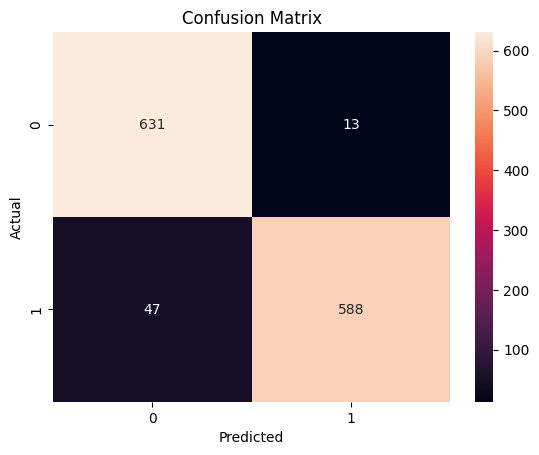

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(true_classes, predicted_classes,target_names=test_generator.class_indices.keys()))

              precision    recall  f1-score   support

    WithMask       0.93      0.98      0.95       644
 WithoutMask       0.98      0.93      0.95       635

    accuracy                           0.95      1279
   macro avg       0.95      0.95      0.95      1279
weighted avg       0.95      0.95      0.95      1279



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step


/tmp/ipython-input-1179639134.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = class_labels[int(prediction > 0.5)]


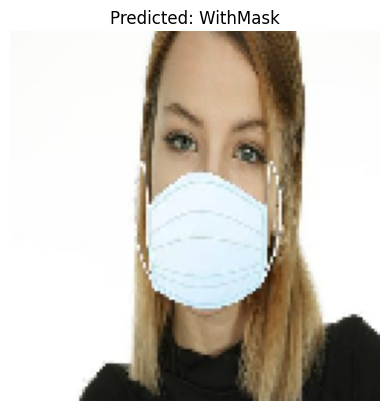

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


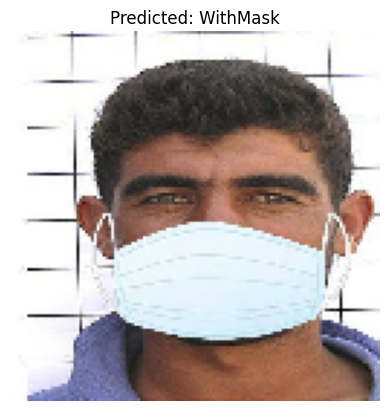

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


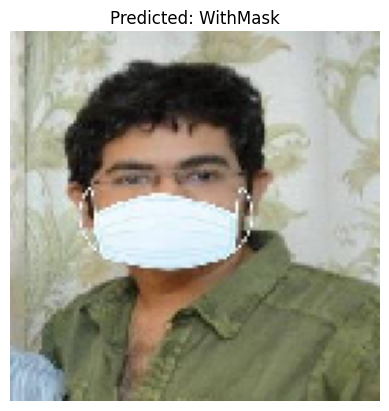

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


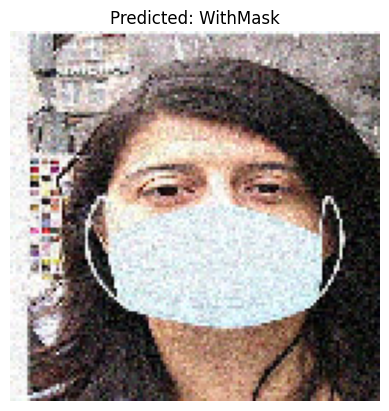

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


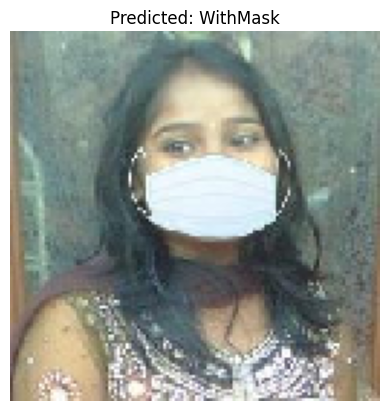

In [ ]:
import random
from tensorflow.keras.preprocessing import image

class_labels = list(test_generator.class_indices.keys())

for i in random.sample(range(len(test_generator.filenames)), 5):
    img_path = test_generator.filepaths[i]

    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    label = class_labels[int(prediction > 0.5)]

    plt.imshow(img)
    plt.title("Predicted: " + label)
    plt.axis('off')
    plt.show()

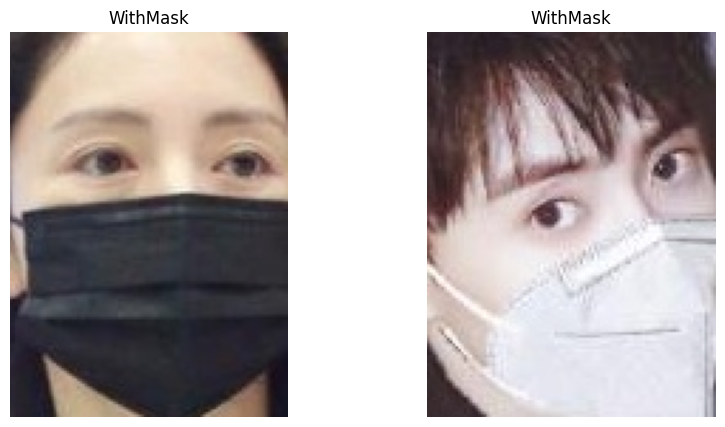

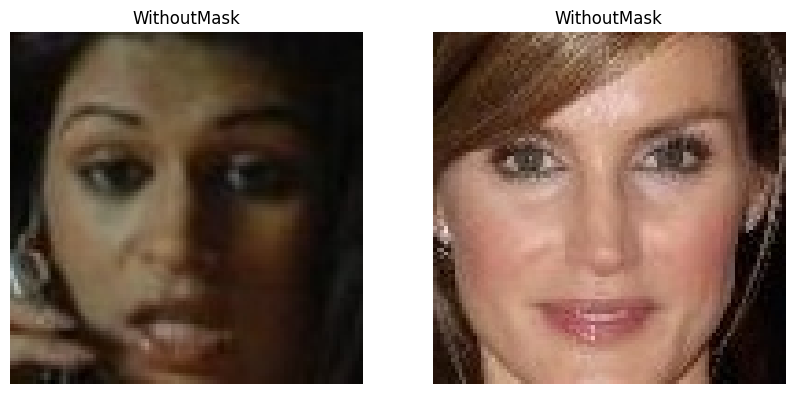

In [ ]:
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image

# Correct folder paths
train_with_mask = "dataset_split/train/withMask"
train_without_mask = "dataset_split/train/withoutMask"

# Function to display sample images at original quality
def show_samples(folder_path, class_name, n=2):
    files = os.listdir(folder_path)
    samples = random.sample(files, n)  # randomly pick n images
    plt.figure(figsize=(5*n, 5))
    for i, img_file in enumerate(samples):
        img_path = os.path.join(folder_path, img_file)
        img = image.load_img(img_path)  # do NOT resize
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
    plt.show()

# Show 2 sample images from each class
show_samples(train_with_mask, "WithMask")
show_samples(train_without_mask, "WithoutMask")

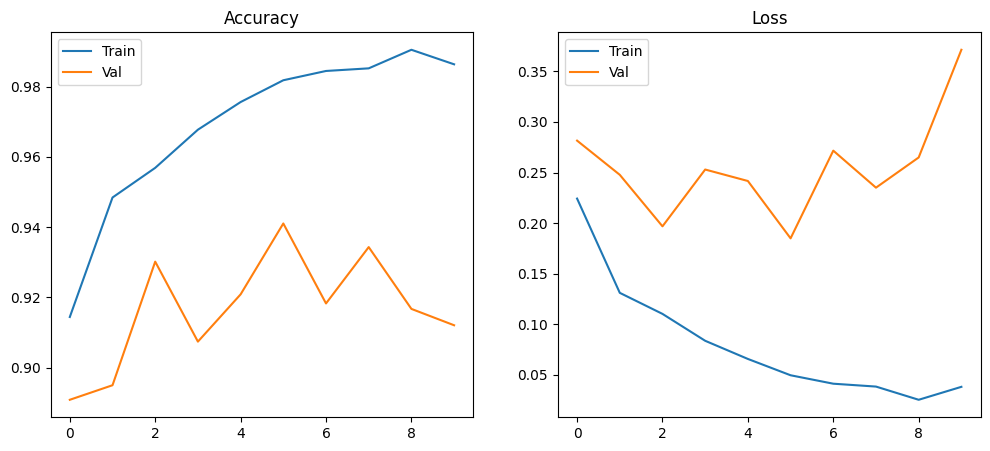

In [ ]:
# Accuracy / Loss plot
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()

40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 456ms/step


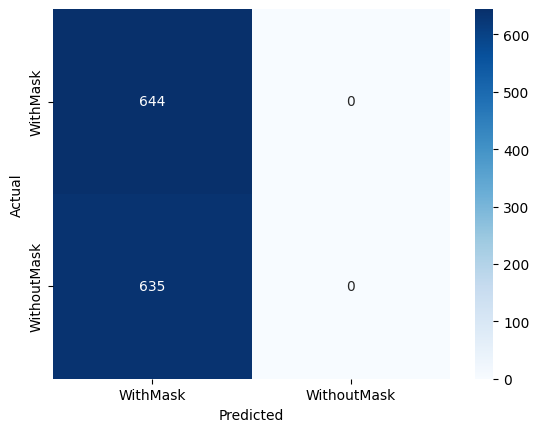

In [ ]:
# Confusion matrix heatmap
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=-1)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices, yticklabels=test_generator.class_indices)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

# Make sure Drive is mounted
model_path = "/content/drive/MyDrive/face_mask_project/face_mask_cnn_model.h5"
model = load_model(model_path)
print("Model loaded successfully!")

Model loaded successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


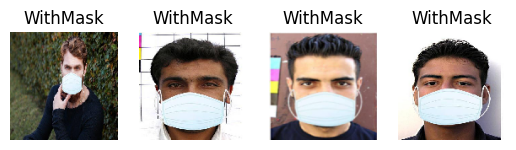

In [ ]:
class_labels = list(test_generator.class_indices.keys())

for i in range(4):
    img_path = test_generator.filepaths[i]
    img = image.load_img(img_path, target_size=(128,128))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    pred = model.predict(x)[0][0]
    predicted_class = 1 if pred > 0.5 else 0
    label = class_labels[predicted_class]

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.show()